# CDC Obesity Data Analysis

## Project Objective

This project analyzes public health data from the CDC to identify which U.S. states have the highest obesity prevalence. The goal is to explore geographic patterns in obesity rates using real public health data.

## Data Collection

Public health data was collected from the CDC PLACES API. This dataset includes health indicators such as obesity prevalence across U.S. states and counties. The data is retrieved using Python and converted into a pandas dataframe for analysis.

In [ ]:
import requests
import pandas as pd

url = "https://data.cdc.gov/resource/cwsq-ngmh.json?$limit=5000"

response = requests.get(url)
data = response.json()

df = pd.DataFrame(data)

df.head()

,year,stateabbr,statedesc,countyname,countyfips,locationname,datasource,category,measure,data_value_unit,...,high_confidence_limit,totalpopulation,totalpop18plus,geolocation,locationid,categoryid,measureid,datavaluetypeid,short_question_text,:@computed_region_skr5_azej
0,2023,AL,Alabama,Jefferson,01073,01073010900,BRFSS,Disability,Any disability among adults,%,...,49.0,4719,3410,"{'type': 'Point', 'coordinates': [-86.7705771,...",01073010900,DISABLT,DISABILITY,CrdPrv,Any Disability,1583
1,2023,AL,Alabama,Jefferson,01073,01073011207,BRFSS,Health Outcomes,Depression among adults,%,...,25.9,5103,3684,"{'type': 'Point', 'coordinates': [-86.6742325,...",01073011207,HLTHOUT,DEPRESSION,CrdPrv,Depression,1583
2,2023,AL,Alabama,Lauderdale,01077,01077010100,BRFSS,Disability,Any disability among adults,%,...,46.2,2278,2093,"{'type': 'Point', 'coordinates': [-87.6598801,...",01077010100,DISABLT,DISABILITY,CrdPrv,Any Disability,1584
3,2023,AL,Alabama,Lee,01081,01081040202,BRFSS,Health Outcomes,Arthritis among adults,%,...,26.2,3084,2459,"{'type': 'Point', 'coordinates': [-85.4521355,...",01081040202,HLTHOUT,ARTHRITIS,CrdPrv,Arthritis,1586
4,2023,AL,Alabama,Lee,01081,01081040300,BRFSS,Health Outcomes,Obesity among adults,%,...,42.2,2576,2188,"{'type': 'Point', 'coordinates': [-85.4668576,...",01081040300,HLTHOUT,OBESITY,CrdPrv,Obesity,1586


## Data Cleaning

The dataset was filtered to include only obesity-related records. The obesity values were converted to numeric format and rows with missing values were removed to ensure accurate analysis.

In [ ]:
obesity_df = df[df["measure"].str.contains("obesity", case=False, na=False)]

obesity_df.head()

,year,stateabbr,statedesc,countyname,countyfips,locationname,datasource,category,measure,data_value_unit,...,high_confidence_limit,totalpopulation,totalpop18plus,geolocation,locationid,categoryid,measureid,datavaluetypeid,short_question_text,:@computed_region_skr5_azej
4,2023,AL,Alabama,Lee,01081,01081040300,BRFSS,Health Outcomes,Obesity among adults,%,...,42.2,2576,2188,"{'type': 'Point', 'coordinates': [-85.4668576,...",01081040300,HLTHOUT,OBESITY,CrdPrv,Obesity,1586
7,2023,AL,Alabama,Lee,01081,01081040602,BRFSS,Health Outcomes,Obesity among adults,%,...,43.9,8254,5751,"{'type': 'Point', 'coordinates': [-85.5181586,...",01081040602,HLTHOUT,OBESITY,CrdPrv,Obesity,1586
9,2023,AL,Alabama,Lee,01081,01081040903,BRFSS,Health Outcomes,Obesity among adults,%,...,38.9,1961,1722,"{'type': 'Point', 'coordinates': [-85.4808959,...",01081040903,HLTHOUT,OBESITY,CrdPrv,Obesity,1586
17,2023,AK,Alaska,Ketchikan Gateway,02130,02130000101,BRFSS,Health Outcomes,Obesity among adults,%,...,44.2,2894,2238,"{'type': 'Point', 'coordinates': [-131.7622852...",02130000101,HLTHOUT,OBESITY,CrdPrv,Obesity,111
19,2023,AK,Alaska,Matanuska-Susitna,02170,02170000101,BRFSS,Health Outcomes,Obesity among adults,%,...,43.5,700,599,"{'type': 'Point', 'coordinates': [-150.4078364...",02170000101,HLTHOUT,OBESITY,CrdPrv,Obesity,1707


In [3]:
import requests
import pandas as pd

url = "https://data.cdc.gov/resource/cwsq-ngmh.json?$limit=5000"

response = requests.get(url)
data = response.json()

df = pd.DataFrame(data)
obesity_df = df[df["measure"].str.contains("obesity", case=False, na=False)]
obesity_df.loc[:, "data_value"] = pd.to_numeric(obesity_df["data_value"], errors="coerce")

## Data Analysis

The dataset was grouped by state to calculate the average obesity rate in each state. This helps identify which states have the highest obesity prevalence.

In [ ]:
state_obesity = obesity_df.groupby("statedesc")["data_value"].mean().sort_values(ascending=False)

state_obesity.head(10)

,data_value
statedesc,
Arkansas,42.180000
Alabama,40.993407
Connecticut,39.100000
Alaska,38.550000
Florida,33.128571
Arizona,33.100000
Delaware,31.200000
Illinois,30.320000
Georgia,30.233333


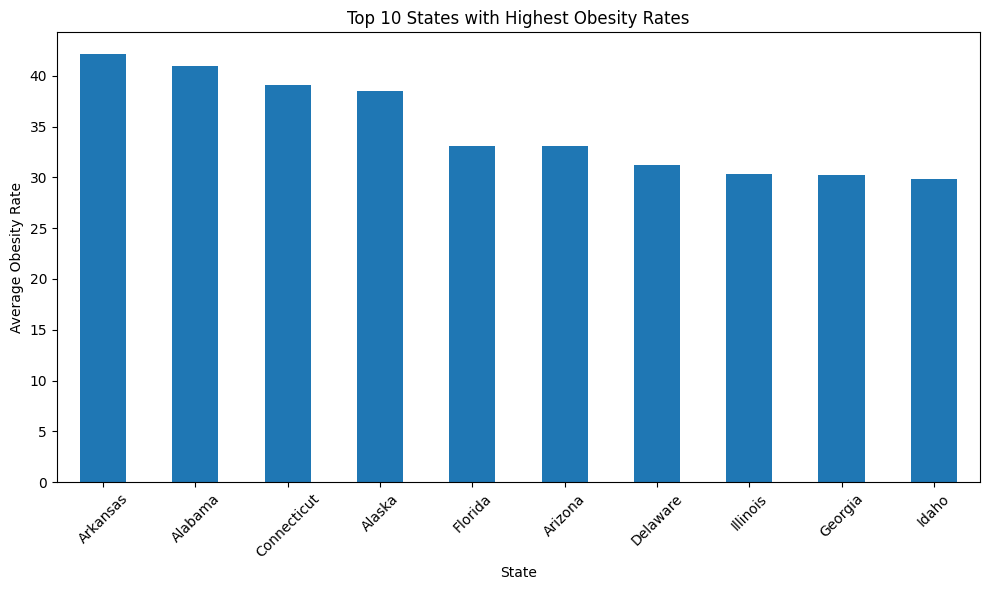

In [ ]:
import matplotlib.pyplot as plt

top10 = state_obesity.head(10)

plt.figure(figsize=(10,6))
top10.plot(kind="bar")

plt.title("Top 10 States with Highest Obesity Rates")
plt.xlabel("State")
plt.ylabel("Average Obesity Rate")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## Key Insights

The analysis shows that certain states have higher obesity prevalence compared to others.
Regional differences may be influenced by lifestyle, socioeconomic conditions, and access to healthcare.
Identifying states with higher obesity rates can help guide public health programs and prevention strategies.

## County-Level Analysis

In [4]:
county_obesity = obesity_df.groupby(["statedesc","countyname"])["data_value"].mean().sort_values(ascending=False)

county_obesity.head(10)


statedesc  countyname
Alabama    Hale          51.225
           Bibb            47.8
           Dallas        47.425
           Barbour        47.25
           Henry           45.9
           Choctaw         44.9
           Franklin        44.8
           Conecuh         44.7
Florida    Union           44.2
Alabama    Chambers        44.1
Name: data_value, dtype: object

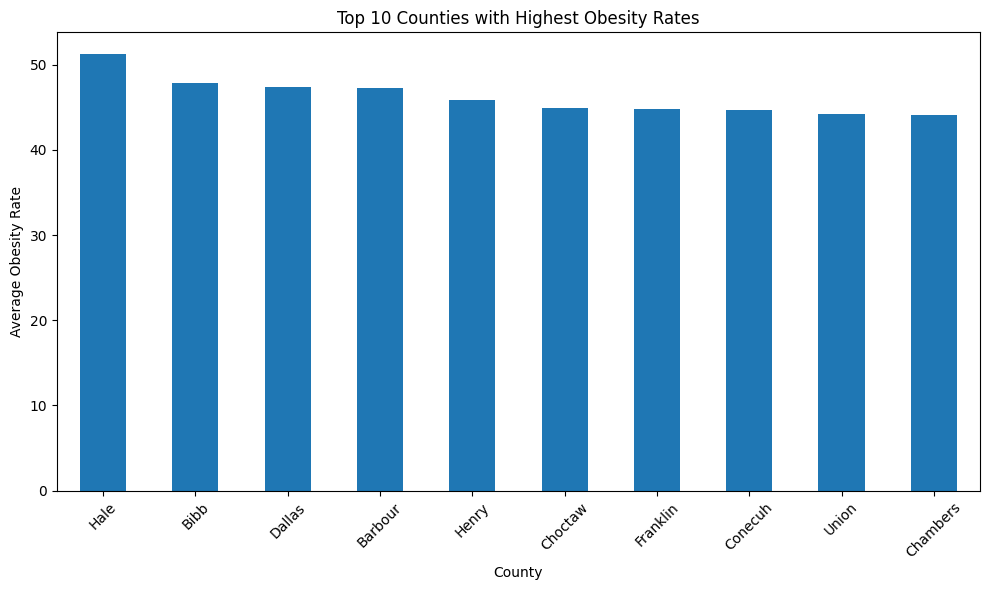

In [ ]:
top_counties = county_obesity.head(10)

plt.figure(figsize=(10,6))
top_counties.plot(kind="bar")

plt.title("Top 10 Counties with Highest Obesity Rates")
plt.xlabel("County")
plt.ylabel("Average Obesity Rate")

plt.xticks(rotation=45)
plt.tight_layout()

plt.show()

## County Insights

County-level analysis reveals additional variation in obesity prevalence within states.
Some counties show significantly higher obesity rates than others, indicating local health disparities.
These results suggest that targeted county-level public health initiatives may be beneficial.

## Distribution of Obesity Rates

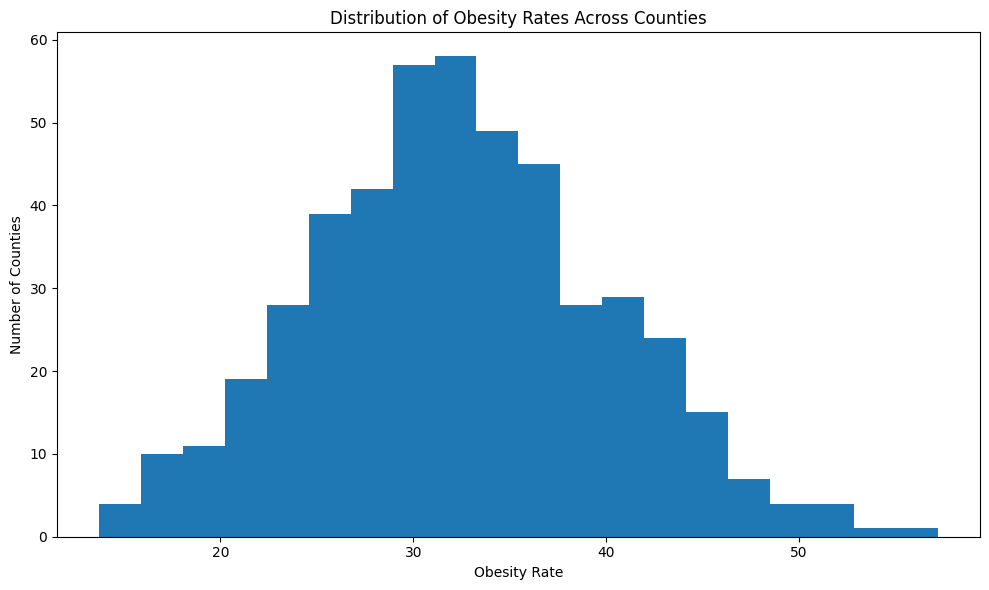

In [ ]:
plt.figure(figsize=(10,6))

plt.hist(obesity_df["data_value"], bins=20)

plt.title("Distribution of Obesity Rates Across Counties")
plt.xlabel("Obesity Rate")
plt.ylabel("Number of Counties")

plt.tight_layout()

plt.show()

## Distribution Insights

The histogram shows how obesity rates are distributed across counties.
Most counties cluster around a similar range of obesity prevalence, while fewer counties appear at the extreme high or low ends.
Understanding this distribution helps identify whether high obesity rates are widespread or concentrated in specific locations.

## Conclusion

This analysis explored obesity prevalence across U.S. states and counties using CDC public health data.
The results show that obesity rates vary across geographic regions, with some states and counties exhibiting higher prevalence than others.
These findings highlight the importance of targeted public health interventions to address obesity and improve population health outcomes.